In [1]:
# 🛠️ Ensemble Learning (Toplu Öğrenme) Özet Notlar

### 1. Bagging (Bootstrap Aggregating)
* **Nedir:** Veriden rastgele alt kümeler seçip, **paralel (bağımsız)** modeller eğitip sonuçları birleştirir.
* **Neden/Ne Zaman:** Model çok karmaşıksa ve **aşırı öğreniyorsa (High Variance / Overfitting)** varyansı düşürmek için kullanılır.
* **Nasıl:** Bağımsız eğit $\rightarrow$ Sonuçları oyla veya ortalamasını al.

### 2. Boosting
* **Nedir:** Modelleri **sıralı (ardışık)** eğitir; her model bir önceki modelin yaptığı hatalara odaklanır.
* **Neden/Ne Zaman:** Model veriyi yeterince öğrenemiyorsa **(High Bias / Underfitting)** yanlılığı azaltıp doğruluğu maksimuma çıkarmak için kullanılır.
* **Nasıl:** İlk modeli eğit $\rightarrow$ Hataların ağırlığını artır $\rightarrow$ Sonraki modeli hataya odakla.

### 3. Random Forest
* **Nedir:** Temelinde **Bagging** kullanan, çok sayıda bağımsız karar ağacından oluşan algoritmadır.
* **Neden/Ne Zaman:** Hem sınıflandırma hem regresyonda; parametre ayarıyla uğraşmadan hızlı, kararlı ve yüksek performanslı bir model kurmak için kullanılır.
* **Nasıl:** Hem satırları (bootstrap) hem de sütunları (özellikleri) rastgele seçerek yüzlerce farklı ağaç oluşturur ve oylama yapar.

SyntaxError: invalid syntax (1665136241.py, line 4)

In [1]:
import numpy as np
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('14-income_evaluation.csv')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

In [6]:
# kolon isimlermiz de yanlislik ve bosluklar var bunlari duzeltmek istiyorum 

In [7]:
col_names = ['age','workclass','finalweight','education','eduacation_num','marital_status','occupation','relationship',
            'race','sex','capital_gain','capital_loss','hours_per_week','native_country','income']

In [8]:
df.columns = col_names 

In [9]:
df.columns

Index(['age', 'workclass', 'finalweight', 'education', 'eduacation_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   finalweight     32561 non-null  int64 
 3   education       32561 non-null  object
 4   eduacation_num  32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [11]:
df.describe()

,age,finalweight,eduacation_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [12]:
df.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
eduacation_num    0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [13]:
for col in df.columns:
    if df[col].dtype == 'O':
        display(df[col])
    

0                State-gov
1         Self-emp-not-inc
2                  Private
3                  Private
4                  Private
               ...        
32556              Private
32557              Private
32558              Private
32559              Private
32560         Self-emp-inc
Name: workclass, Length: 32561, dtype: object

0          Bachelors
1          Bachelors
2            HS-grad
3               11th
4          Bachelors
            ...     
32556     Assoc-acdm
32557        HS-grad
32558        HS-grad
32559        HS-grad
32560        HS-grad
Name: education, Length: 32561, dtype: object

0              Never-married
1         Married-civ-spouse
2                   Divorced
3         Married-civ-spouse
4         Married-civ-spouse
                ...         
32556     Married-civ-spouse
32557     Married-civ-spouse
32558                Widowed
32559          Never-married
32560     Married-civ-spouse
Name: marital_status, Length: 32561, dtype: object

0              Adm-clerical
1           Exec-managerial
2         Handlers-cleaners
3         Handlers-cleaners
4            Prof-specialty
                ...        
32556          Tech-support
32557     Machine-op-inspct
32558          Adm-clerical
32559          Adm-clerical
32560       Exec-managerial
Name: occupation, Length: 32561, dtype: object

0         Not-in-family
1               Husband
2         Not-in-family
3               Husband
4                  Wife
              ...      
32556              Wife
32557           Husband
32558         Unmarried
32559         Own-child
32560              Wife
Name: relationship, Length: 32561, dtype: object

0         White
1         White
2         White
3         Black
4         Black
          ...  
32556     White
32557     White
32558     White
32559     White
32560     White
Name: race, Length: 32561, dtype: object

0           Male
1           Male
2           Male
3           Male
4         Female
          ...   
32556     Female
32557       Male
32558     Female
32559       Male
32560     Female
Name: sex, Length: 32561, dtype: object

0         United-States
1         United-States
2         United-States
3         United-States
4                  Cuba
              ...      
32556     United-States
32557     United-States
32558     United-States
32559     United-States
32560     United-States
Name: native_country, Length: 32561, dtype: object

0         <=50K
1         <=50K
2         <=50K
3         <=50K
4         <=50K
          ...  
32556     <=50K
32557      >50K
32558     <=50K
32559     <=50K
32560      >50K
Name: income, Length: 32561, dtype: object

In [14]:
# bana sadece objectleri getirmesini istedim ama boyle cok anlali olmadi 

In [15]:
categorial = [col for col in df.columns if df[col].dtype == 'O']
numerical = [col for col in df.columns if df[col].dtype != 'O']

In [16]:
categorial

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [17]:
numerical

['age',
 'finalweight',
 'eduacation_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

In [18]:
# bu sekilde tablomuzu grupladim

In [19]:
df[categorial].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [20]:
df[numerical].head()

,age,finalweight,eduacation_num,capital_gain,capital_loss,hours_per_week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


In [21]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [22]:
# inbalance bir durum yok vermizde 

In [23]:
for col in categorial :
    print(df[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

In [24]:
# kolonlarimiz kategorik degerlerine baktim isnull yaptigimda bos veri gozukmuyordu ama bence bos verilere bu dataset de ? koyulmus 

In [25]:
# EDA 

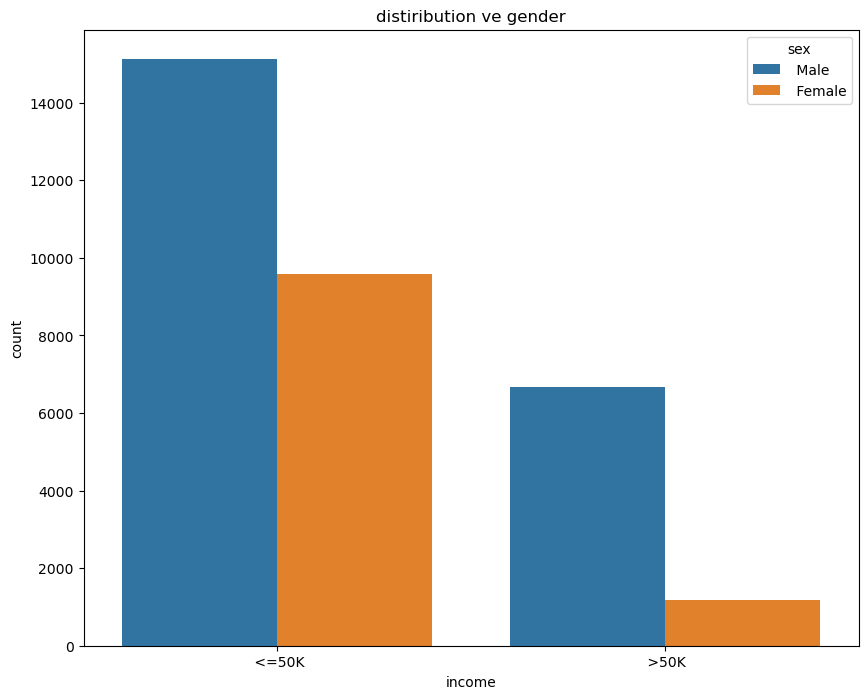

In [26]:
fig , ax = plt.subplots(figsize=(10,8))
ax = sns.countplot(x='income',hue='sex',data=df)
ax.set_title('distiribution ve gender')
plt.show()

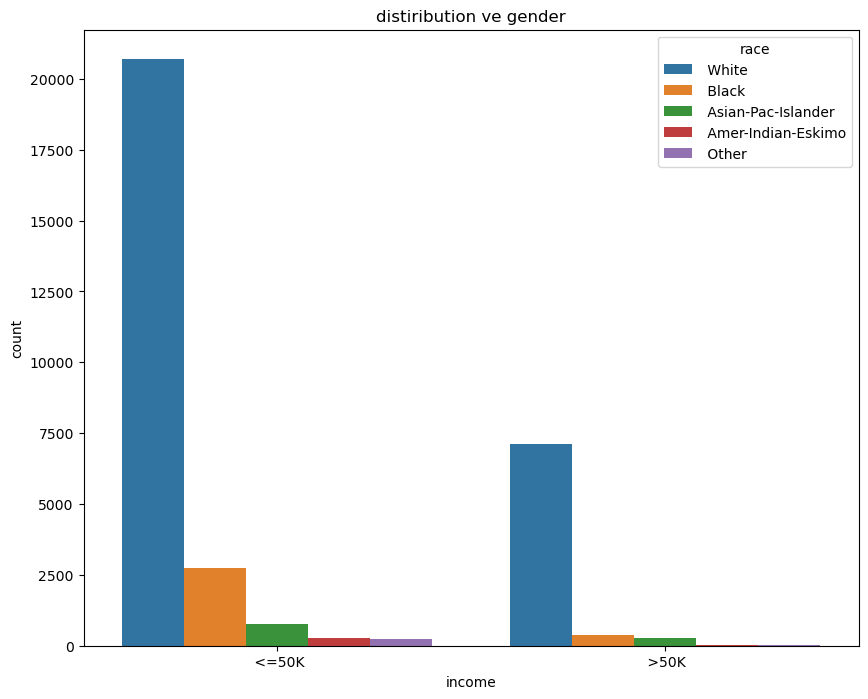

In [27]:
fig , ax = plt.subplots(figsize=(10,8))
ax = sns.countplot(x='income',hue='race',data=df)
ax.set_title('distiribution ve gender')
plt.show()

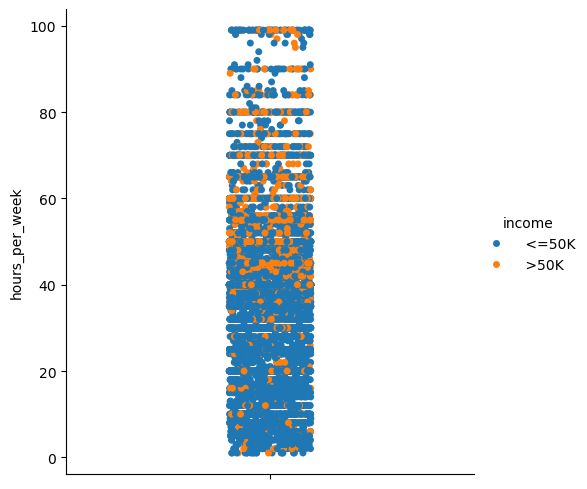

In [28]:
sns.catplot(y=df['hours_per_week'],hue=df['income'])
plt.show()

In [29]:
# genelde zenginler 40 saatden fazla calisan kisilermis genel olarak bu yorumu yapa bilirim kac kisi olduguna bakalim 

In [30]:
ust40 = df[df['hours_per_week'] > 40 ]
alt40 = df[df['hours_per_week'] < 40 ]

In [31]:
ust40['income'].value_counts() 

income
<=50K    5725
>50K     3856
Name: count, dtype: int64

In [32]:
alt40['income'].value_counts()

income
<=50K    7025
>50K      738
Name: count, dtype: int64

In [33]:
# simdide soru isareti kismina odaklanmak istiyorum vermi daha temiz bir hale getirmeye calisacam 

In [34]:
df['workclass'].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [35]:
df['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [36]:
df['workclass'] = df['workclass'].replace(' ?',np.nan)

In [37]:
df['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [38]:
df['education'].unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [39]:
df['marital_status'].unique()

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [40]:
df['occupation'].unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [41]:
df['occupation'] = df['occupation'].replace(' ?',np.nan)

In [42]:
df['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [43]:
df['sex'].unique()

array([' Male', ' Female'], dtype=object)

In [44]:
categorial

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [45]:
df['race'].unique()

array([' White', ' Black', ' Asian-Pac-Islander', ' Amer-Indian-Eskimo',
       ' Other'], dtype=object)

In [46]:
df['relationship'].unique()

array([' Not-in-family', ' Husband', ' Wife', ' Own-child', ' Unmarried',
       ' Other-relative'], dtype=object)

In [47]:
df['native_country'].unique()

array([' United-States', ' Cuba', ' Jamaica', ' India', ' ?', ' Mexico',
       ' South', ' Puerto-Rico', ' Honduras', ' England', ' Canada',
       ' Germany', ' Iran', ' Philippines', ' Italy', ' Poland',
       ' Columbia', ' Cambodia', ' Thailand', ' Ecuador', ' Laos',
       ' Taiwan', ' Haiti', ' Portugal', ' Dominican-Republic',
       ' El-Salvador', ' France', ' Guatemala', ' China', ' Japan',
       ' Yugoslavia', ' Peru', ' Outlying-US(Guam-USVI-etc)', ' Scotland',
       ' Trinadad&Tobago', ' Greece', ' Nicaragua', ' Vietnam', ' Hong',
       ' Ireland', ' Hungary', ' Holand-Netherlands'], dtype=object)

In [48]:
df['native_country'] = df['native_country'].replace(' ?',np.nan)

In [49]:
df.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
eduacation_num       0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

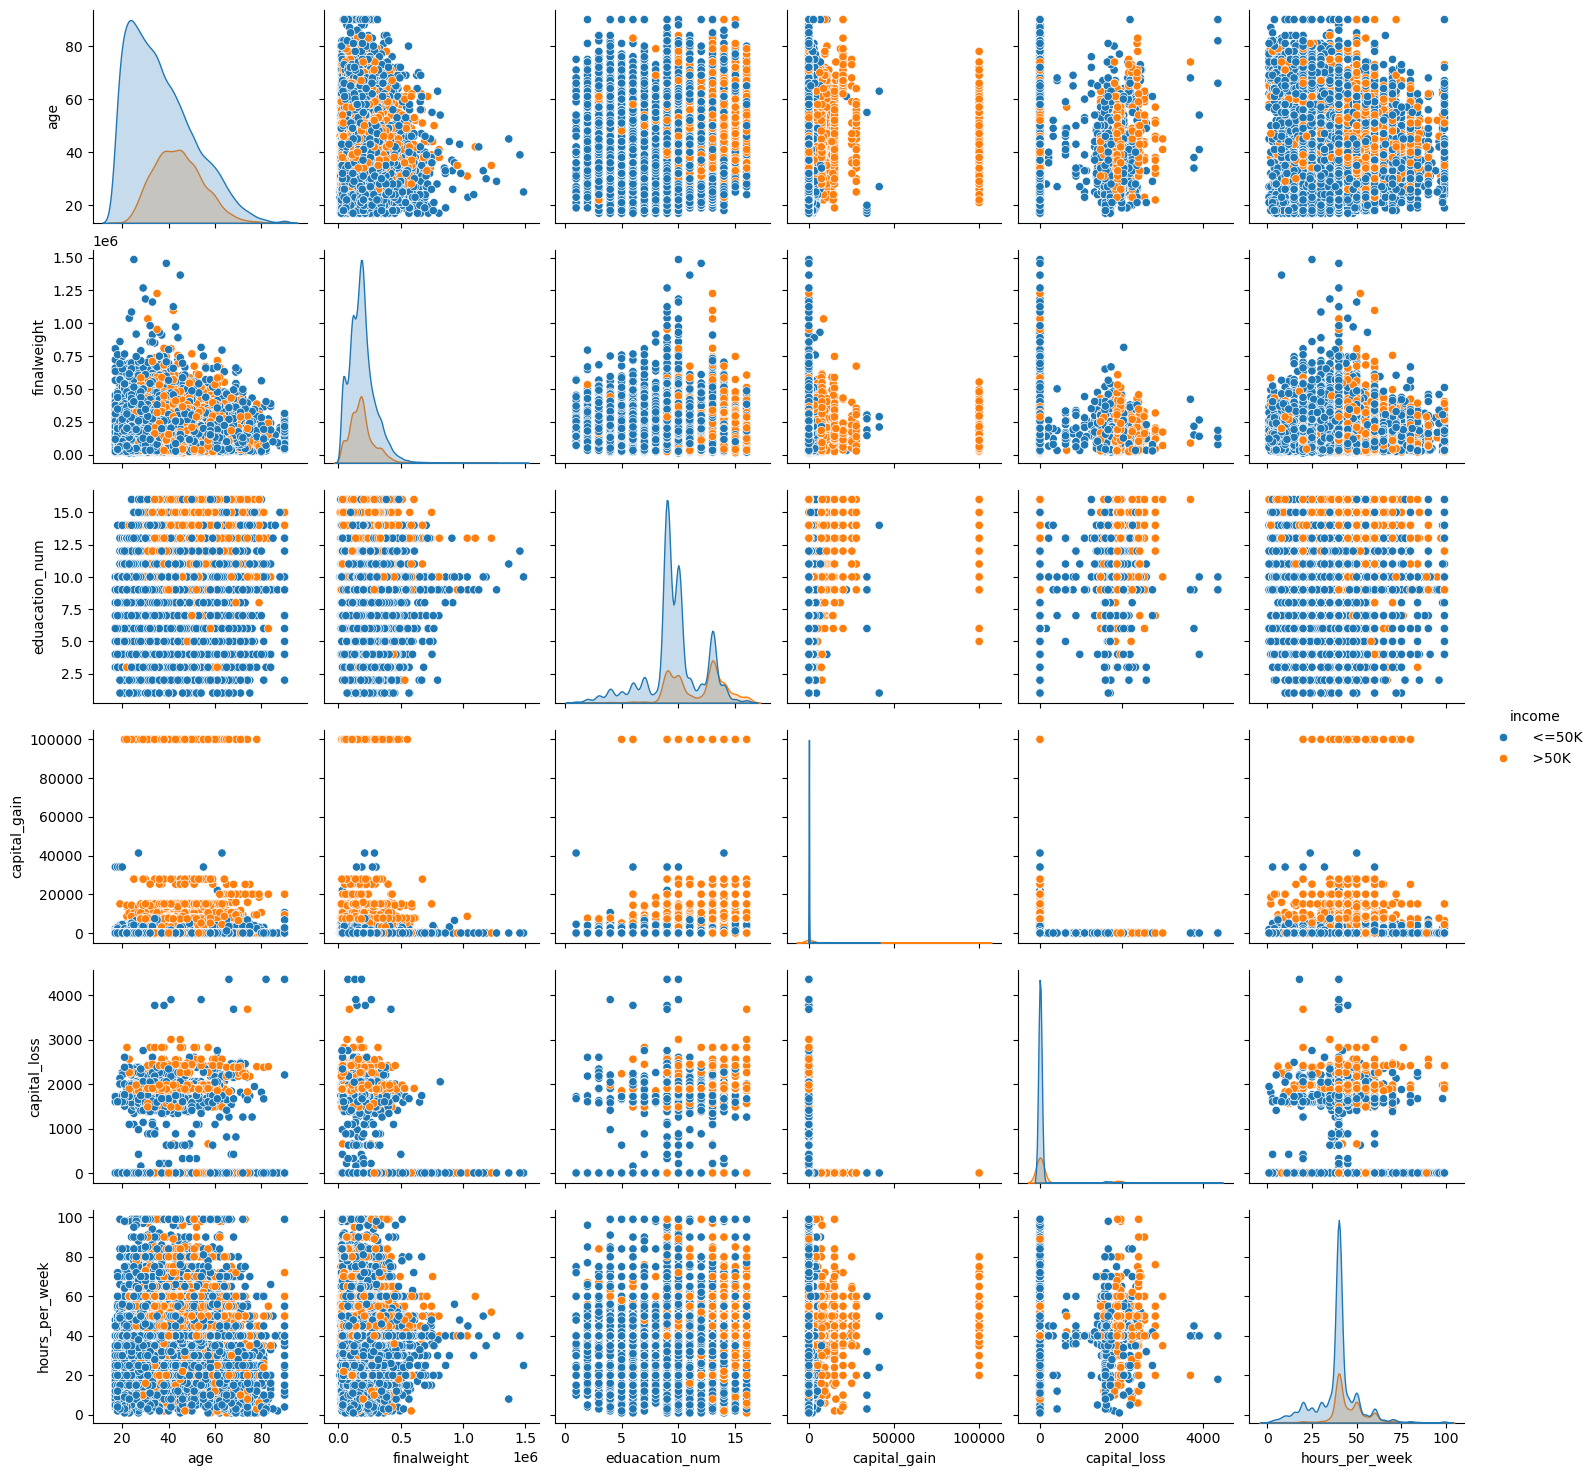

In [50]:
sns.pairplot(df,hue='income')
plt.show()

In [51]:
X = df.drop('income',axis=1)
y = df['income']

In [52]:
from sklearn.model_selection import train_test_split 

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [54]:
X_train.head()

,age,workclass,finalweight,education,eduacation_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
8985,28,NaN,196630,Assoc-voc,11,Separated,NaN,Unmarried,White,Female,0,0,40,Mexico
19275,64,Private,102041,11th,7,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States
15353,19,Private,458558,HS-grad,9,Married-civ-spouse,Craft-repair,Wife,White,Female,0,0,40,United-States
11272,40,Private,136986,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,50,United-States
16221,21,NaN,262062,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,40,United-States


In [55]:
categorial = [col for col in X_train.columns if X_train[col].dtype == 'O']

In [56]:
X_train[categorial].isnull().sum()

workclass         1368
education            0
marital_status       0
occupation        1371
relationship         0
race                 0
sex                  0
native_country     423
dtype: int64

In [57]:
X_test[categorial].isnull().sum()

workclass         468
education           0
marital_status      0
occupation        472
relationship        0
race                0
sex                 0
native_country    160
dtype: int64

In [58]:
X_train['workclass'].mode()

0     Private
Name: workclass, dtype: object

In [59]:
for i in [X_train,X_test]:
    i['workclass'] = i['workclass'].fillna(X_train['workclass'].mode()[0])
    i['occupation'] = i['occupation'].fillna(X_train['occupation'].mode()[0])
    i['native_country'] = i['native_country'].fillna(X_train['native_country'].mode()[0])

In [60]:
X_train[categorial].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64

In [61]:
X_test[categorial].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64

In [62]:
# ENCODING 

In [63]:
X_train[categorial].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
8985,Private,Assoc-voc,Separated,Prof-specialty,Unmarried,White,Female,Mexico
19275,Private,11th,Married-civ-spouse,Sales,Husband,White,Male,United-States
15353,Private,HS-grad,Married-civ-spouse,Craft-repair,Wife,White,Female,United-States
11272,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States
16221,Private,Some-college,Never-married,Prof-specialty,Own-child,White,Female,United-States


In [64]:
df[categorial].nunique()

workclass          8
education         16
marital_status     7
occupation        14
relationship       6
race               5
sex                2
native_country    41
dtype: int64

In [65]:
# country kisminda cok vazla deger var ve one encoding yaptigim bu bizek cok fazla dert olucak bundan dolayi ulkeleri para kazanma degerine gore
# 0 ve 1 ayiricam

In [66]:
y_train_binary = y_train.apply(lambda x:1 if x.strip() == '>50K' else 0 ) # strip eger bosluklar falan filan varsa kodumuz takilmasin diye 

In [67]:
target_means = y_train_binary.groupby(X_train['native_country']).mean()

In [68]:
X_train['native_country_encoded'] = X_train['native_country'].map(target_means)
X_train['native_country_encoded'] = X_train['native_country_encoded'].fillna(y_train_binary.mean())

X_test['native_country_encoded'] = X_test['native_country'].map(target_means)
X_test['native_country_encoded'] = X_test['native_country_encoded'].fillna(y_train_binary.mean())

In [69]:
X_train.head()

,age,workclass,finalweight,education,eduacation_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,native_country_encoded
8985,28,Private,196630,Assoc-voc,11,Separated,Prof-specialty,Unmarried,White,Female,0,0,40,Mexico,0.061224
19275,64,Private,102041,11th,7,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,0.246417
15353,19,Private,458558,HS-grad,9,Married-civ-spouse,Craft-repair,Wife,White,Female,0,0,40,United-States,0.246417
11272,40,Private,136986,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,50,United-States,0.246417
16221,21,Private,262062,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,40,United-States,0.246417


In [70]:
# artik native country kolonumuza gerek kaldami bundan dolayi silme islemi yapicam

In [71]:
X_train = X_train.drop('native_country',axis=1)
X_test = X_test.drop('native_country',axis=1)

In [72]:
categorial

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [73]:
one_hot_categories = ['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',]

In [74]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [75]:
one_hot_categories = [col for col in one_hot_categories if col in X_train.columns]

In [76]:
encoder = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False),one_hot_categories)
    ], remainder = 'passthrough'
)

In [77]:
# --- TEKRAR NOTLARI ---
# ColumnTransformer: Farklı sütunlara (sayısal/kategorik) aynı anda farklı işlemler uygulamayı sağlayan ana çatı.
# 'cat': Bu adıma verilen keyfi isim (categorical kısaltması), hata veya çıktı takibinde kolaylık sağlar.
# OneHotEncoder: Kategorik (metin) verileri, modelin anlayacağı 0 ve 1'lerden oluşan sütunlara dönüştürür.
# handle_unknown='ignore': Test verisinde eğitimde hiç görülmemiş yeni bir değer çıkarsa hata verme, 0 bas geç der.
# one_hot_categories: Bu One-Hot işleminin sadece hangi sütunlara uygulanacağını belirten isim listesi.
# remainder='passthrough': İşlem görmeyen diğer (sayısal) sütunları silme, aynen olduğu gibi koruyarak sona ekle.

In [78]:
X_train_enc = encoder.fit_transform(X_train)
X_test_enc =  encoder.transform(X_test)

In [79]:
X_train_enc

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.00000000e+01, 6.12244898e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.00000000e+01, 2.46417055e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.00000000e+01, 2.46417055e-01],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 5.00000000e+01, 2.46417055e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.57900000e+03, 4.00000000e+01, 2.46417055e-01],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.00000000e+01, 2.46417055e-01]])

In [80]:
# one hot endocdingde kolalarimiz degistigi icin bunlari bir yere kaydetmek iyi olur ilerde  gormek veya islem yapmak icin isimizze yarayabilir

In [81]:
columns = encoder.get_feature_names_out()

In [82]:
columns

array(['cat__workclass_ Federal-gov', 'cat__workclass_ Local-gov',
       'cat__workclass_ Never-worked', 'cat__workclass_ Private',
       'cat__workclass_ Self-emp-inc', 'cat__workclass_ Self-emp-not-inc',
       'cat__workclass_ State-gov', 'cat__workclass_ Without-pay',
       'cat__education_ 10th', 'cat__education_ 11th',
       'cat__education_ 12th', 'cat__education_ 1st-4th',
       'cat__education_ 5th-6th', 'cat__education_ 7th-8th',
       'cat__education_ 9th', 'cat__education_ Assoc-acdm',
       'cat__education_ Assoc-voc', 'cat__education_ Bachelors',
       'cat__education_ Doctorate', 'cat__education_ HS-grad',
       'cat__education_ Masters', 'cat__education_ Preschool',
       'cat__education_ Prof-school', 'cat__education_ Some-college',
       'cat__marital_status_ Divorced',
       'cat__marital_status_ Married-AF-spouse',
       'cat__marital_status_ Married-civ-spouse',
       'cat__marital_status_ Married-spouse-absent',
       'cat__marital_status_ Never-mar

In [83]:
# basliklarimiz hemen df cevirlim 

In [84]:
X_train = pd.DataFrame(X_train_enc,columns=columns,index=X_train.index)
X_test = pd.DataFrame(X_test_enc,columns=columns,index=X_test.index)

In [85]:
X_train

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__eduacation_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
8985,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,28.0,196630.0,11.0,0.0,0.0,40.0,0.061224
19275,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,64.0,102041.0,7.0,0.0,0.0,40.0,0.246417
15353,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,19.0,458558.0,9.0,0.0,0.0,40.0,0.246417
11272,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,40.0,136986.0,10.0,0.0,0.0,50.0,0.246417
16221,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,21.0,262062.0,10.0,0.0,0.0,40.0,0.246417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16247,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,376455.0,11.0,0.0,0.0,38.0,0.246417
2693,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,24.0,145964.0,13.0,0.0,0.0,40.0,0.246417
8076,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,50.0,136913.0,9.0,0.0,0.0,50.0,0.246417
20213,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,25.0,182227.0,9.0,0.0,1579.0,40.0,0.246417


In [86]:
X_test

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__eduacation_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
10125,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,47.0,182752.0,9.0,0.0,0.0,35.0,0.400000
11478,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,73.0,161027.0,3.0,0.0,0.0,20.0,0.246417
4224,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,18.0,152182.0,10.0,0.0,0.0,25.0,0.246417
6592,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,66.0,284021.0,9.0,0.0,0.0,40.0,0.246417
21910,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,39.0,261504.0,8.0,0.0,0.0,40.0,0.246417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18656,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,24.0,149457.0,10.0,0.0,0.0,40.0,0.246417
14618,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,38.0,203482.0,4.0,0.0,0.0,45.0,0.246417
15017,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,48.0,175221.0,9.0,0.0,0.0,40.0,0.246417
2973,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,187046.0,9.0,0.0,0.0,40.0,0.246417


In [87]:
cols = X_train.columns

In [88]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

In [89]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
X_train = pd.DataFrame(X_train,columns=cols)

In [91]:
X_train

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__eduacation_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.45,0.155999,0.333333,0.0,0.0,0.0,-0.185193
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.35,-0.637898,-1.000000,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.90,2.354391,-0.333333,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.15,-0.344600,0.000000,0.0,0.0,2.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.80,0.705177,0.000000,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24415,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.05,1.665291,0.333333,0.0,0.0,-0.4,0.000000
24416,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.65,-0.269247,1.000000,0.0,0.0,0.0,0.000000
24417,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.65,-0.345213,-0.333333,0.0,0.0,2.0,0.000000
24418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.60,0.035113,-0.333333,0.0,1579.0,0.0,0.000000


In [92]:
X_test = pd.DataFrame(X_test,columns=cols)

In [93]:
X_test

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__eduacation_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.50,0.039519,-0.333333,0.0,0.0,-1.0,0.153583
1,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.80,-0.142821,-2.333333,0.0,0.0,-4.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.95,-0.217059,0.000000,0.0,0.0,-3.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,1.45,0.889482,-0.333333,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.10,0.700494,-0.666667,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.65,-0.239930,0.000000,0.0,0.0,0.0,0.000000
8137,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.05,0.213508,-2.000000,0.0,0.0,1.0,0.000000
8138,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.55,-0.023690,-0.333333,0.0,0.0,0.0,0.000000
8139,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.05,0.075559,-0.333333,0.0,0.0,0.0,0.000000


In [94]:
# Training 

In [95]:
from sklearn.ensemble import  RandomForestClassifier

In [96]:
rfc = RandomForestClassifier(n_estimators=10,random_state=15) # estiamtor kac tane agac oldugunu gosterir bize 
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=15)

In [97]:
y_pred = rfc.predict(X_test)

In [98]:
from sklearn.metrics import  accuracy_score , classification_report,confusion_matrix

In [99]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8537034762314212
[[5756  431]
 [ 760 1194]]
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      6187
        >50K       0.73      0.61      0.67      1954

    accuracy                           0.85      8141
   macro avg       0.81      0.77      0.79      8141
weighted avg       0.85      0.85      0.85      8141



In [100]:
rfc = RandomForestClassifier(n_estimators=100,random_state=15) 
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8647586291610367
[[5765  422]
 [ 679 1275]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      6187
        >50K       0.75      0.65      0.70      1954

    accuracy                           0.86      8141
   macro avg       0.82      0.79      0.81      8141
weighted avg       0.86      0.86      0.86      8141



In [101]:
rfc = RandomForestClassifier(n_estimators=1000,random_state=15) 
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8651271342586906
[[5767  420]
 [ 678 1276]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      6187
        >50K       0.75      0.65      0.70      1954

    accuracy                           0.87      8141
   macro avg       0.82      0.79      0.81      8141
weighted avg       0.86      0.87      0.86      8141



In [102]:
rfc.feature_importances_

array([5.77858021e-03, 6.00795047e-03, 9.93161773e-09, 1.12108818e-02,
       5.84369590e-03, 8.49943229e-03, 4.65463472e-03, 1.09250677e-05,
       1.37500174e-03, 1.85884204e-03, 7.91429301e-04, 2.27294076e-04,
       7.18825020e-04, 1.80224826e-03, 1.15837749e-03, 2.48383802e-03,
       2.92417972e-03, 1.19422023e-02, 3.68036644e-03, 7.23127482e-03,
       7.87763521e-03, 6.06651717e-05, 4.52176910e-03, 5.49745711e-03,
       5.59819362e-03, 4.98489285e-04, 6.58813859e-02, 9.44046025e-04,
       2.15403300e-02, 1.47696567e-03, 1.59863309e-03, 6.01186470e-03,
       8.95078952e-06, 7.16909563e-03, 1.86101554e-02, 4.42003959e-03,
       3.16044937e-03, 4.41351288e-03, 6.76111861e-03, 9.24875973e-05,
       1.06222702e-02, 3.28184196e-03, 7.46123791e-03, 4.81557154e-03,
       4.99077802e-03, 4.80804712e-02, 1.00099148e-02, 1.24642068e-03,
       7.52345971e-03, 4.59665796e-03, 1.03639850e-02, 1.29965680e-03,
       3.31751520e-03, 5.01724612e-03, 9.47738026e-04, 7.00483397e-03,
      

In [103]:
# rfc.feature_importances_: Modelin hedef değişkeni (geliri) tahmin ederken hangi sütuna ne kadar güvendiğini ve 
# hangi özelliğin ne kadar önemli olduğunu gösteren skor matrisidir.

In [104]:
pd.set_option('display.float_format', lambda x: '%.6f' % x)

In [105]:
pd.Series(rfc.feature_importances_,index=X_train.columns).sort_values(ascending=False)

remainder__finalweight             0.161227
remainder__age                     0.151074
remainder__capital_gain            0.097425
remainder__hours_per_week          0.082805
remainder__eduacation_num          0.069100
                                     ...   
cat__occupation_ Priv-house-serv   0.000092
cat__education_ Preschool          0.000061
cat__workclass_ Without-pay        0.000011
cat__occupation_ Armed-Forces      0.000009
cat__workclass_ Never-worked       0.000000
Length: 65, dtype: float64

In [106]:
feature_scores = pd.Series(rfc.feature_importances_,index=X_train.columns).sort_values(ascending=False)

In [107]:
feature_scores.tail(10)

cat__marital_status_ Married-spouse-absent   0.000944
cat__education_ 12th                         0.000791
cat__education_ 5th-6th                      0.000719
cat__marital_status_ Married-AF-spouse       0.000498
cat__education_ 1st-4th                      0.000227
cat__occupation_ Priv-house-serv             0.000092
cat__education_ Preschool                    0.000061
cat__workclass_ Without-pay                  0.000011
cat__occupation_ Armed-Forces                0.000009
cat__workclass_ Never-worked                 0.000000
dtype: float64

In [108]:
X_train = X_train.drop(['cat__marital_status_ Married-spouse-absent','cat__education_ 12th','cat__education_ 5th-6th','cat__marital_status_ Married-AF-spouse',
                       'cat__education_ 1st-4th','cat__occupation_ Priv-house-serv','cat__education_ Preschool','cat__workclass_ Without-pay',
                       'cat__workclass_ Without-pay','cat__occupation_ Armed-Forces','cat__workclass_ Never-worked'],axis=1)

In [109]:
X_test = X_test.drop(['cat__marital_status_ Married-spouse-absent','cat__education_ 12th','cat__education_ 5th-6th','cat__marital_status_ Married-AF-spouse',
                       'cat__education_ 1st-4th','cat__occupation_ Priv-house-serv','cat__education_ Preschool','cat__workclass_ Without-pay',
                       'cat__workclass_ Without-pay','cat__occupation_ Armed-Forces','cat__workclass_ Never-worked'],axis=1)

In [110]:
rfc = RandomForestClassifier(n_estimators=100,random_state=15) 
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8619334234123572
[[5765  422]
 [ 702 1252]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      6187
        >50K       0.75      0.64      0.69      1954

    accuracy                           0.86      8141
   macro avg       0.82      0.79      0.80      8141
weighted avg       0.86      0.86      0.86      8141



In [111]:
# etkisi dusuk olan vermilermizi cikatgimiz zaman degerimiz biraz daha artmis oldu 

In [113]:
# HYPERPARAMETER  TUNING 

In [115]:
rf_params = {
    'n_estimators' : [100,200,500,1000],
     'max_depth' : [5,8,10,15,None],
     'max_features': ['sqrt','log2',5,6,7,8],
     'min_samples_split':[2,8,15,20]}

In [116]:
from sklearn.model_selection import RandomizedSearchCV

In [117]:
rfc = RandomForestClassifier()

In [119]:
rscv = RandomizedSearchCV(estimator=rfc,param_distributions=rf_params,cv=3,n_jobs=-1)
rscv.fit(X_train,y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 8, 10, 15, None],
                                        'max_features': ['sqrt', 'log2', 5, 6,
                                                         7, 8],
                                        'min_samples_split': [2, 8, 15, 20],
                                        'n_estimators': [100, 200, 500, 1000]})

In [120]:
y_pred = rscv.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8695491954305368
[[5810  377]
 [ 685 1269]]
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      6187
        >50K       0.77      0.65      0.70      1954

    accuracy                           0.87      8141
   macro avg       0.83      0.79      0.81      8141
weighted avg       0.86      0.87      0.87      8141



In [121]:
# accurancy i % 86 ya kadar cikartabildik vermizide 